# Cambios en el consumo a nivel local

In [2]:
import pandas as pd

from glob import glob
from matplotlib import pyplot as plt

In [3]:
# List of input files
files = glob('data/data_*.csv')

# Concatenate vertically
df = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)

print(df.columns)

Index(['hour', 'zip_code', 'food', 'restaurants', 'hotels', 'health',
       'airlines', 'services', 'goods', 'leisure', 'gasoline', 'total',
       'transaction_online', 'transaction_physical', 'date'],
      dtype='object')


In [4]:
df['hour'] = df['hour'].apply(int)
df = df.query('hour >= 0 and hour <= 23')

In [5]:
id_cols = ['hour', 'date', 'zip_code']

In [6]:
for c in df.columns:
    nulls_abs = len(df) - len(df[c].dropna())
    nulls_per = "{:.1f}".format(100 * nulls_abs / len(df))
    print(c, '.' * (30-len(c)), nulls_abs, '\t', f'{nulls_per}%')

hour .......................... 0 	 0.0%
zip_code ...................... 0 	 0.0%
food .......................... 68495 	 19.9%
restaurants ................... 200709 	 58.2%
hotels ........................ 306536 	 88.9%
health ........................ 214052 	 62.1%
airlines ...................... 342905 	 99.4%
services ...................... 161909 	 46.9%
goods ......................... 16422 	 4.8%
leisure ....................... 336435 	 97.6%
gasoline ...................... 313321 	 90.9%
total ......................... 0 	 0.0%
transaction_online ............ 344876 	 100.0%
transaction_physical .......... 344876 	 100.0%
date .......................... 0 	 0.0%


In [7]:
df = df.drop(columns=['transaction_online', 'transaction_physical', 'goods', 'services'])

In [8]:
value_cols = sorted([c for c in df.columns if c not in id_cols])

for c in value_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

In [9]:
df[value_cols].describe().round(0)

,airlines,food,gasoline,health,hotels,leisure,restaurants,total
count,1971.0,276381.0,31555.0,130824.0,38340.0,8441.0,144167.0,344876.0
mean,170621.0,20699.0,12347.0,7292.0,6651.0,99077.0,12627.0,147175.0
std,1408810.0,276405.0,21452.0,25059.0,40574.0,395280.0,44956.0,1657843.0
min,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2674.0,568.0,2280.0,429.0,650.0,720.0,676.0,1078.0
50%,12241.0,1785.0,7606.0,1508.0,1588.0,3351.0,2675.0,5071.0
75%,41579.0,5861.0,16459.0,6129.0,4508.0,20908.0,9339.0,26383.0
max,36419421.0,16823310.0,1055972.0,4636101.0,6551939.0,11088402.0,5085481.0,127481478.0


In [14]:
df

,hour,zip_code,food,restaurants,hotels,health,airlines,leisure,gasoline,total,date
0,8,08800,168.5,NaN,NaN,NaN,NaN,NaN,NaN,168.50,2025-05-23
1,11,09839,642.0,NaN,NaN,NaN,NaN,NaN,NaN,8252.00,2025-05-23
2,20,11260,791.5,NaN,NaN,7800.61,NaN,NaN,NaN,8592.11,2025-05-23
3,14,09839,364.0,NaN,NaN,NaN,NaN,NaN,NaN,3641.00,2025-05-23
4,0,11040,NaN,NaN,8532.0,NaN,NaN,NaN,NaN,985216.90,2025-05-23
...,...,...,...,...,...,...,...,...,...,...,...
347714,5,10400,NaN,NaN,NaN,926.00,NaN,NaN,NaN,926.00,2025-05-23
347715,5,07050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,797.00,2025-05-23
347716,14,16750,2166.0,NaN,NaN,NaN,NaN,NaN,NaN,2166.00,2025-05-23
347717,10,08800,181.5,NaN,NaN,NaN,NaN,NaN,NaN,181.50,2025-05-23


In [16]:
df_cdmx = df.copy()
df_cdmx['zip_code'] = '00000'
df_cdmx = df_cdmx.groupby(id_cols).sum().reset_index()
df = pd.concat([df, df_cdmx], ignore_index=True)
del df_cdmx

In [17]:
df

,hour,zip_code,food,restaurants,hotels,health,airlines,leisure,gasoline,total,date
0,8,08800,168.50,NaN,NaN,NaN,NaN,NaN,NaN,1.685000e+02,2025-05-23
1,11,09839,642.00,NaN,NaN,NaN,NaN,NaN,NaN,8.252000e+03,2025-05-23
2,20,11260,791.50,NaN,NaN,7800.61,NaN,NaN,NaN,8.592110e+03,2025-05-23
3,14,09839,364.00,NaN,NaN,NaN,NaN,NaN,NaN,3.641000e+03,2025-05-23
4,0,11040,NaN,NaN,8532.00,NaN,NaN,NaN,NaN,9.852169e+05,2025-05-23
...,...,...,...,...,...,...,...,...,...,...,...
345327,23,00000,12391589.45,1645169.79,181933.26,522906.54,209336.00,970334.31,362820.33,1.012835e+08,2025-05-28
345328,23,00000,12011389.10,2589763.72,304707.56,555754.34,166635.19,1240171.77,409956.24,1.022273e+08,2025-05-29
345329,23,00000,10682170.66,3826759.25,331579.97,498886.96,217074.29,1259264.70,451381.64,1.041209e+08,2025-05-30
345330,23,00000,12377360.35,6810506.29,387745.08,515753.20,184525.01,2171997.37,543216.62,9.692913e+07,2025-05-31


In [10]:
df_hour = df.copy()
df_day = df.copy().drop(columns='hour').groupby(['date', 'zip_code']).sum().reset_index()

for f in ('min', 'max'):
    df_agg_hour = df.copy().drop(columns='hour').groupby(['date', 'zip_code']).agg(f).reset_index()
    df_hour = df_hour.merge(df_agg_hour, on=['date', 'zip_code'], how='left', suffixes=(None, f'_{f}'))
    
    df_agg_day = df_day.copy().drop(columns='date').groupby(['zip_code']).agg(f).reset_index()
    df_day = df_day.merge(df_agg_day, on=['zip_code'], how='left', suffixes=(None, f'_{f}'))

df_day['hour'] = -1

df = pd.concat([df, df_day], ignore_index=True)
df_scaled = pd.concat([df_day, df_hour], ignore_index=True)

del df_hour
del df_day

for c in value_cols:
    df_scaled[c] = (df_scaled[c] - df_scaled[f'{c}_min']) / (df_scaled[f'{c}_max'] - df_scaled[f'{c}_min'])

df = df[id_cols + value_cols]
df_scaled = df_scaled[id_cols + value_cols]

In [11]:
df_scaled[value_cols].apply(['min', 'max']).T

,min,max
airlines,0.0,1.0
food,0.0,1.0
gasoline,0.0,1.0
health,0.0,1.0
hotels,0.0,1.0
leisure,0.0,1.0
restaurants,0.0,1.0
total,0.0,1.0


In [12]:
len(df), len(df_scaled)

(364502, 364502)

In [13]:
len(df[id_cols]) - len(df_scaled[id_cols].drop_duplicates()), len(df[id_cols]) - len(df_scaled[id_cols].drop_duplicates())

(0, 0)

In [14]:
def compare(query, category, bins=None):
    plt.rcParams['figure.figsize'] = 6, 3
    fig, axes = plt.subplots(1, 2)
    axes[0].hist(df.query(query)[category], bins=bins)
    axes[1].hist(df_scaled.query(query)[category], bins=bins)
    #fig.suptitle(query.replace(' and', ',').replace(' ==', ':').replace('"', ''))
    for i in (0, 1):
        axes[i].set_title(('Original', 'Escalado')[i])
    plt.tight_layout()
    plt.show()

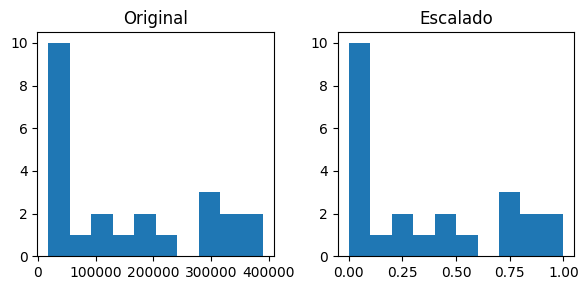

In [15]:
query = 'date == "2025-05-25" and zip_code == "06050" and hour != -1'
category = 'total'
compare(query, category)

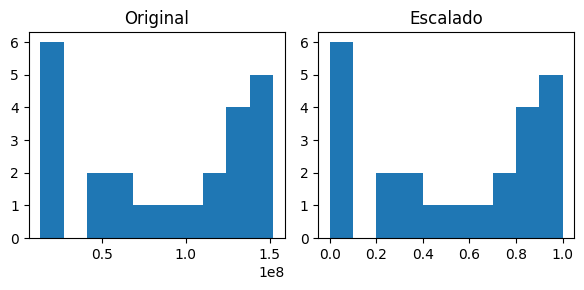

In [16]:
query = 'date == "2025-05-25" and zip_code == "00000" and hour != -1'
category = 'total'
compare(query, category)

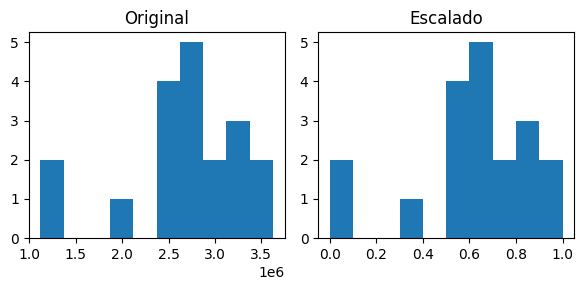

In [17]:
query = 'zip_code == "06050" and hour == -1'
category = 'total'
compare(query, category)

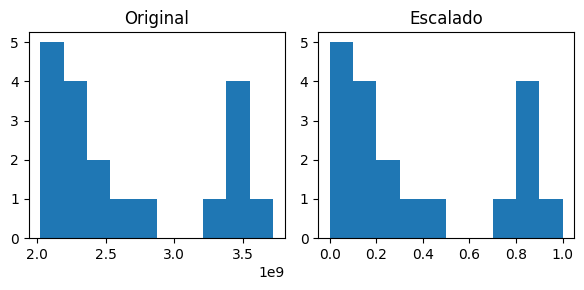

In [18]:
query = 'zip_code == "00000" and hour == -1'
category = 'total'
compare(query, category)

In [30]:
df_export = df_scaled.copy().round(4)
df_export['time'] = df_export['hour'].apply(lambda x: f'T{str(x).zfill(2)}:00:00Z' if x != -1 else 'T00:00:00Z')
df_export['frequency'] = df_export['hour'].apply(lambda x: 'd' if x == -1 else 'h')
df_export['datetime'] = df_export['date'] + df_export['time']
df_export = df_export.drop(columns='time')[['frequency', 'date', 'datetime', 'zip_code'] + value_cols]
df_export

,frequency,date,datetime,zip_code,airlines,food,gasoline,health,hotels,leisure,restaurants,total
0,d,2025-05-14,2025-05-14T00:00:00Z,00000,0.0943,0.1281,0.5025,0.5760,0.0951,0.1422,0.2021,0.1872
1,d,2025-05-14,2025-05-14T00:00:00Z,01000,NaN,0.1672,0.1332,0.7582,NaN,NaN,0.1666,0.7220
2,d,2025-05-14,2025-05-14T00:00:00Z,01010,NaN,0.8396,NaN,0.1904,NaN,NaN,0.3510,0.4270
3,d,2025-05-14,2025-05-14T00:00:00Z,01020,NaN,1.0000,NaN,0.2205,0.3928,NaN,0.0259,0.3146
4,d,2025-05-14,2025-05-14T00:00:00Z,01030,NaN,0.3332,NaN,0.0961,0.0000,NaN,0.1403,0.1013
...,...,...,...,...,...,...,...,...,...,...,...,...
364497,h,2025-05-28,2025-05-28T23:00:00Z,00000,0.0055,0.3596,0.1954,0.0760,0.1185,0.2515,0.2118,0.2197
364498,h,2025-05-29,2025-05-29T23:00:00Z,00000,0.0059,0.3941,0.1969,0.0866,0.2502,0.2812,0.3364,0.2309
364499,h,2025-05-30,2025-05-30T23:00:00Z,00000,0.0085,0.3562,0.2265,0.0317,0.3433,0.3042,0.4118,0.2593
364500,h,2025-05-31,2025-05-31T23:00:00Z,00000,0.0080,0.3301,0.2226,0.0638,0.1398,0.6283,0.6215,0.2503


In [31]:
df_export.to_csv('data_consumption.csv', index=False)

In [20]:
cnte = pd.read_csv('cnte.csv')
cnte.head(3)

,date,time,action_type,location,latitude,longitude,notes,source
0,2025-05-15,09:00,Marcha,Ángel de la Independencia,19.423,-99.167,Inicio de la mega marcha hacia el Zócalo,https://www.milenio.com/politica/comunidad/mar...
1,2025-05-15,13:00,Plantón,Zócalo,19.433,-99.132,Instalación de plantón indefinido,https://www.tvazteca.com/aztecanoticias/planto...
2,2025-05-20,08:00,Bloqueo,Auditorio Nacional,19.422,-99.191,Bloqueo simultáneo anunciado,https://www.telediario.mx/comunidad/bloqueos-d...


In [21]:
cnte = cnte.rename(columns={'time': 'hour'})
cnte['hour'] = cnte['hour'].apply(lambda x: int(x.split(':')[0]))

In [22]:
cnte = cnte[[c for c in cnte.columns if c != 'source']]
cnte

,date,hour,action_type,location,latitude,longitude,notes
0,2025-05-15,9,Marcha,Ángel de la Independencia,19.4230,-99.1670,Inicio de la mega marcha hacia el Zócalo
1,2025-05-15,13,Plantón,Zócalo,19.4330,-99.1320,Instalación de plantón indefinido
2,2025-05-20,8,Bloqueo,Auditorio Nacional,19.4220,-99.1910,Bloqueo simultáneo anunciado
3,2025-05-20,8,Bloqueo,Intercambio La Raza,19.4620,-99.1460,Bloqueo simultáneo anunciado
4,2025-05-20,8,Bloqueo,Calz. de Tlalpan & Gral. Anaya,19.3600,-99.1500,Bloqueo simultáneo anunciado
5,2025-05-20,8,Bloqueo,Zaragoza & Blvd. Puerto Aéreo,19.4280,-99.0790,Bloqueo simultáneo anunciado
6,2025-05-22,14,Bloqueo,Paseo de la Reforma (Gral. Prim),19.4310,-99.1530,Cierre de carriles laterales
7,2025-05-23,12,Concentración,Zócalo,19.4330,-99.1320,Concentración prevista
8,2025-05-23,12,Bloqueo,AICM Terminal 1 accesos,19.4360,-99.0730,Bloqueo de accesos vehiculares al aeropuerto
9,2025-06-02,10,Bloqueo,Secretaría de Gobernación (Bucareli & Abraham ...,19.4308,-99.1537,"Bloqueo en Segob; cierre de Bucareli, Abraham ..."


In [23]:
cnte.to_csv('data_cnte.csv', index=False)